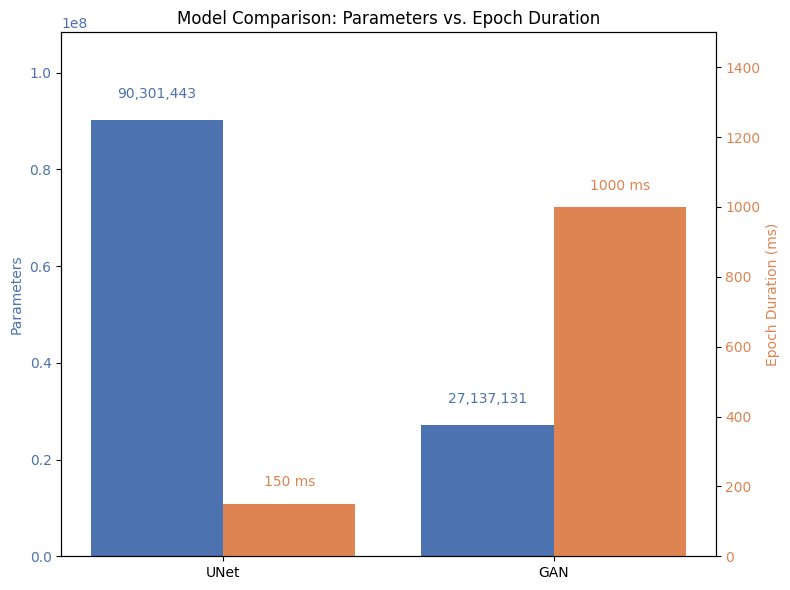

In [8]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# Data
models = ["UNet", "GAN"]
param_counts = [90301443, 8888490 + 18248641]  # UNet, GAN total
epoch_times = [150, 1000]  # in milliseconds

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot parameters on left Y-axis
color1 = "#4C72B0"
bars1 = ax1.bar(models, param_counts, color=color1, width=0.4, label='Parameters')
ax1.set_ylabel("Parameters", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, max(param_counts)*1.2)

# Add value labels
for i, val in enumerate(param_counts):
    ax1.text(i, val + max(param_counts)*0.05, f'{val:,}', ha='center', color=color1)

# Create second Y-axis
ax2 = ax1.twinx()
color2 = "#DD8452"
bars2 = ax2.bar([i + 0.4 for i in range(len(models))], epoch_times, width=0.4, color=color2, label='Epoch Duration')
ax2.set_ylabel("Epoch Duration (ms)", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, max(epoch_times)*1.5)

# Add value labels
for i, val in enumerate(epoch_times):
    ax2.text(i + 0.4, val + max(epoch_times)*0.05, f'{val} ms', ha='center', color=color2)

# Title and formatting
plt.title("Model Comparison: Parameters vs. Epoch Duration")
ax1.set_xticks([i + 0.2 for i in range(len(models))])
ax1.set_xticklabels(models)

fig.tight_layout()
plt.show()


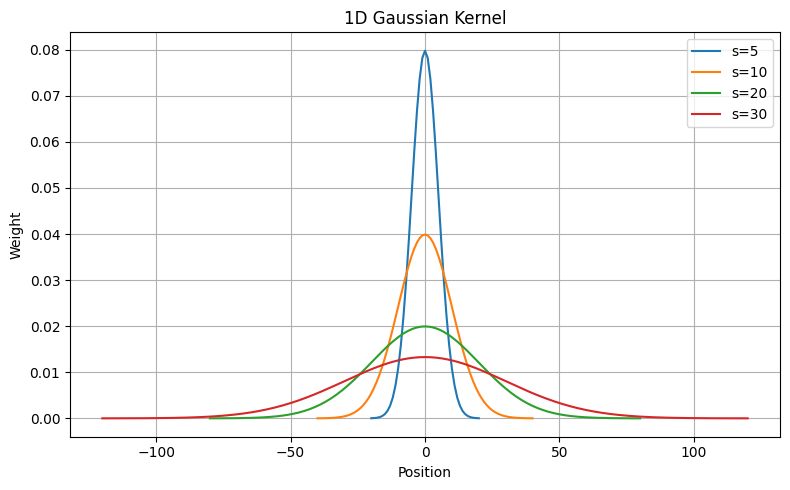

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def compute_kernel(sigma=1.0, truncate=4.0):
    radius = int(truncate * sigma)
    kernel_size = 2 * radius + 1
    x = np.linspace(-radius, radius, kernel_size)
    
    # 1D Gaussian values
    kernel = norm.pdf(x, loc=0, scale=sigma)
    kernel /= kernel.sum()  # Normalize
    return x, kernel


plt.figure(figsize=(8, 5))
sigmas = [5, 10, 20, 30]
for s in sigmas:
    plt.plot(*compute_kernel(s), label=f's={s}')

plt.title("1D Gaussian Kernel")
plt.xlabel("Position")
plt.ylabel("Weight")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()




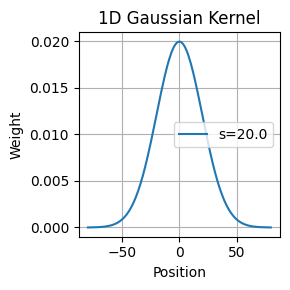

In [7]:

visualize_gaussian_kernel_1d(sigma=20.0)

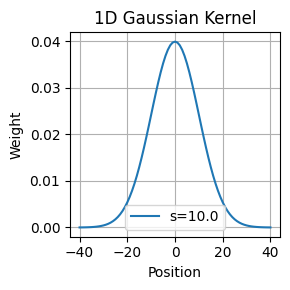

In [8]:
visualize_gaussian_kernel_1d(sigma=10.0)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def visualize_dog_1d(sigma1=1.0, sigma2=3.0, truncate=4.0):
    # Define kernel size large enough for both sigmas
    radius = int(truncate * max(sigma1, sigma2))
    kernel_size = 2 * radius + 1
    x = np.linspace(-radius, radius, kernel_size)

    # Build both Gaussians
    g1 = norm.pdf(x, loc=0, scale=sigma1)
    g2 = norm.pdf(x, loc=0, scale=sigma2)

    # Normalize
    g1 /= g1.sum()
    g2 /= g2.sum()

    # DoG = G1 - G2
    dog = g1 - g2

    # Plot
    plt.figure(figsize=(8, 4))
    plt.plot(x, g1, label=f'G1 (σ={sigma1})')
    plt.plot(x, g2, label=f'G2 (σ={sigma2})')
    plt.plot(x, dog, label='DoG = G1 - G2', color='black', linewidth=2)
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.title('Difference of Gaussians (DoG) - 1D Band-Pass Filter')
    plt.xlabel('Position')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


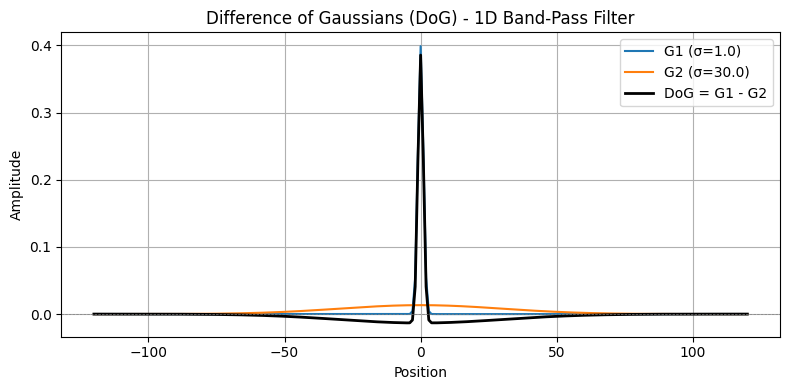

In [3]:
visualize_dog_1d(sigma1=1.0, sigma2=30.0)


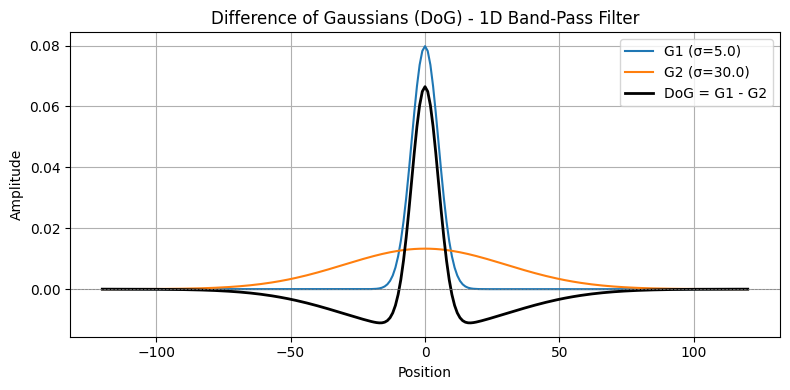

In [12]:
visualize_dog_1d(sigma1=5.0, sigma2=30.0)

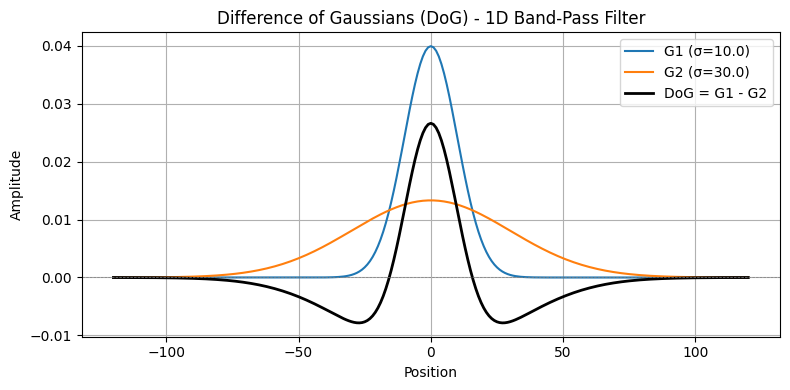

In [13]:
visualize_dog_1d(sigma1=10.0, sigma2=30.0)

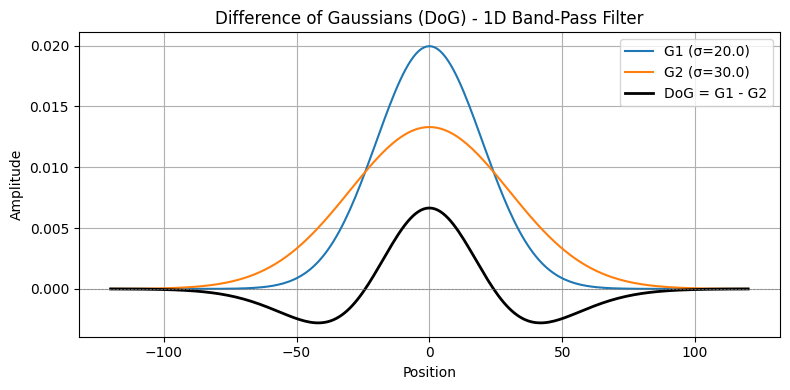

In [14]:
visualize_dog_1d(sigma1=20.0, sigma2=30.0)

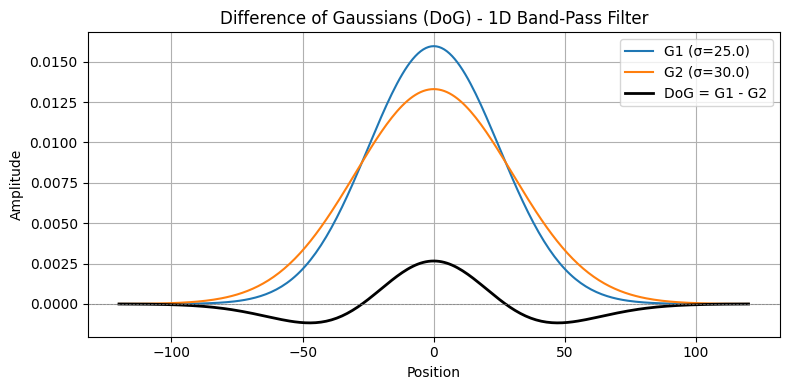

In [15]:
visualize_dog_1d(sigma1=25.0, sigma2=30.0)